In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
import numpy as np

sns.set_context("paper")

def drop_ambiguous_proteins(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.contains(";", regex=False)]

quant = pd.read_csv("../../data/covid/raw/prot_quant_clin_meas.tsv", sep="	", encoding="latin-1").set_index("Measurement").head(328).T
meta = pd.read_csv("../../data/covid/raw/prot_quant_clin_meas_meta.tsv", sep="	", encoding="latin-1").set_index("File")

quant_inns = pd.read_csv("../../data/covid/raw/innsbruck_quant.tsv", sep="	", encoding="latin-1").set_index("Genes").T
meta_inns = pd.read_csv("../../data/covid/raw/innsbruck_meta.tsv", sep="	", encoding="latin-1").set_index("File.Name")

quant = drop_ambiguous_proteins(quant)
quant_inns = drop_ambiguous_proteins(quant_inns)

proteins = list(quant.columns)
samples = list(quant.index)
quant

Measurement,A1BG,A2M,ACTBL2,ADIPOQ,AFM,AGT,AHSG,ALB,ALDOA,AMBP,...,SERPINA3,SERPINA4,SERPINA5,SERPINA6,SERPINA7,SERPINC1,SERPIND1,SERPINF1,SERPINF2,SERPING1
520_TOF1_AF_002_ZeBanC_P1_A1,1693.843385,4902.456223,59.734972,11.524088,162.966391,671.313100,736.639556,64573.590319,NaN,5816.988158,...,10922.410663,93.688234,NaN,432.889485,195.175013,1455.192527,511.978668,339.833143,976.721716,3772.456507
520_TOF1_AF_003_ZeBanC_P1_A2,1880.097657,4431.701765,24.969049,NaN,220.963692,652.742062,693.456793,64627.476546,NaN,1248.299057,...,12756.716410,166.212728,NaN,330.862322,157.911230,1612.555999,557.574323,210.771330,868.404395,4381.779821
520_TOF1_AF_004_ZeBanC_P1_A3,2232.778954,5430.228557,NaN,NaN,208.999292,458.611410,1020.926268,67225.273657,NaN,1358.959881,...,8221.535616,129.485793,NaN,316.983732,143.313557,1582.797174,698.964989,182.599569,669.815477,3396.995476
520_TOF1_AF_005_ZeBanC_P1_A4,1870.803048,3496.458518,51.815772,NaN,76.404891,485.896995,417.886091,66407.601513,NaN,1551.479044,...,11994.262885,81.073224,NaN,193.106891,145.172608,1345.954389,480.256063,335.209916,662.272699,2203.756180
520_TOF1_AF_006_ZeBanC_P1_A5,1744.692651,4121.831697,37.457218,18.515725,264.498199,683.573484,1025.331266,61915.160588,NaN,3137.503580,...,9492.145606,82.991945,NaN,374.336822,276.347447,1223.297106,494.171203,297.976349,751.187261,3599.681991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710_TOF1_LS_473_ZeBanc2_P5_A12,1651.164684,4998.035843,NaN,NaN,147.665736,484.991154,892.682401,80104.758511,NaN,4332.275026,...,6727.451934,111.861694,NaN,315.704717,98.324352,1712.010416,361.181366,300.865022,733.941681,2657.969428
710_TOF1_LS_475_ZeBanc2_P2_H1,1360.572476,4754.362573,NaN,NaN,337.524041,400.654565,1536.146791,100576.351851,NaN,2102.974318,...,3481.506353,191.051414,NaN,234.178864,162.086253,1648.710294,675.041482,199.955997,664.229385,2301.337241
710_TOF1_LS_476_ZeBanc2_P3_F11,1656.406873,10369.463424,NaN,NaN,451.095601,372.902195,2425.561315,154293.101676,NaN,1566.839583,...,2181.825030,226.566960,NaN,394.221697,137.266209,2300.118847,646.700603,176.084685,765.162247,2518.754707
710_TOF1_LS_477_ZeBanc2_P5_H12,1379.295597,6421.937582,47.610683,NaN,328.191518,646.537290,743.417823,114388.721253,NaN,3673.328636,...,3844.725978,273.717234,NaN,325.363607,131.341987,1551.120159,348.243577,319.207815,649.689853,3493.351467


In [2]:
quant_inns = quant_inns.dropna(how="any",axis=1)
inns_proteins = list(quant_inns.columns)
len(inns_proteins)

111

In [3]:
quant = quant.dropna(how="any",axis=1)
proteins = list(quant.columns)
len(proteins)

105

In [4]:
proteins_inner_set = [p for p in inns_proteins if p in proteins]
proteins = proteins_inner_set
len(proteins)

94

In [5]:
quant_inns = quant_inns[proteins]
quant = quant[proteins]

In [6]:
merged_inns = meta_inns.merge(quant_inns, left_index=True, right_index=True)
merged = meta.merge(quant, left_index=True, right_index=True)
merged

,Patient Id,Time point - days since admission,Time point - days until outcome,WHO grade,Max severity,Patient died,Will worsen in the future,DNI / DNR,Secondary DNI / DNR,Age,...,ORM1,APOA2,APOC2,PON1,SERPIND1,GPX3,LUM,C1QC,HBA1,IGKV4-1
File,,,,,,,,,,,,,,,,,,,,,
520_TOF1_AF_002_ZeBanC_P1_A1,123,23,5.0,7,7,1,1,0,0,53,...,10194.398850,535.159955,2494.275437,222.199506,511.978668,121.322065,218.204982,793.482478,8705.667946,2305.275909
520_TOF1_AF_003_ZeBanC_P1_A2,42,21,52.0,6,7,0,1,0,0,69,...,7578.613910,1391.871378,1236.184729,218.356707,557.574323,168.557130,259.363005,1198.017857,541.394103,2786.756377
520_TOF1_AF_004_ZeBanC_P1_A3,42,31,42.0,6,7,0,0,0,0,69,...,6916.079416,2198.326118,1064.933219,218.038673,698.964989,165.460071,294.684591,921.415880,1379.446200,4176.213208
520_TOF1_AF_005_ZeBanC_P1_A4,109,32,13.0,6,7,0,0,0,0,60,...,4749.782935,1689.488255,1210.933221,249.474544,480.256063,228.479540,185.640884,1053.975442,1100.774532,5388.919115
520_TOF1_AF_006_ZeBanC_P1_A5,26,34,70.0,7,7,1,1,0,1,81,...,11749.145040,2024.440623,2017.881710,304.063201,494.171203,185.257000,324.346053,1313.279021,496.455853,2922.025505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710_TOF1_LS_473_ZeBanc2_P5_A12,7,37,62.0,7,7,0,0,0,0,58,...,6870.838201,2353.918345,2606.054761,434.098621,361.181366,94.390662,273.936782,1664.678825,972.888454,3324.108318
710_TOF1_LS_475_ZeBanc2_P2_H1,84,58,9.0,3,6,0,0,0,0,59,...,4050.322275,4230.126327,2557.736491,648.300447,675.041482,115.966543,312.009408,964.944500,950.621005,3395.938491
710_TOF1_LS_476_ZeBanc2_P3_F11,160,69,-55.0,0,5,0,0,0,0,59,...,1924.635659,5603.595547,1199.442601,559.298834,646.700603,215.715003,494.090234,989.141769,2281.090372,4078.456864


In [7]:
merged_inns.rename(columns = {"I.WHO":"WHO grade"}, inplace=True)
merged_inns["dataset"] = "Innsbruck"
merged["dataset"] = "Charite"
merged = pd.concat([merged, merged_inns])
merged["WHO grade"] = merged["WHO grade"].replace(0, 3)
merged

,Patient Id,Time point - days since admission,Time point - days until outcome,WHO grade,Max severity,Patient died,Will worsen in the future,DNI / DNR,Secondary DNI / DNR,Age,...,PON1,SERPIND1,GPX3,LUM,C1QC,HBA1,IGKV4-1,dataset,Id,SP.Date
520_TOF1_AF_002_ZeBanC_P1_A1,123.0,23.0,5.0,7,7.0,1.0,1.0,0.0,0.0,53.0,...,222.199506,511.978668,121.322065,218.204982,793.482478,8705.667946,2305.275909,Charite,NaN,NaN
520_TOF1_AF_003_ZeBanC_P1_A2,42.0,21.0,52.0,6,7.0,0.0,1.0,0.0,0.0,69.0,...,218.356707,557.574323,168.557130,259.363005,1198.017857,541.394103,2786.756377,Charite,NaN,NaN
520_TOF1_AF_004_ZeBanC_P1_A3,42.0,31.0,42.0,6,7.0,0.0,0.0,0.0,0.0,69.0,...,218.038673,698.964989,165.460071,294.684591,921.415880,1379.446200,4176.213208,Charite,NaN,NaN
520_TOF1_AF_005_ZeBanC_P1_A4,109.0,32.0,13.0,6,7.0,0.0,0.0,0.0,0.0,60.0,...,249.474544,480.256063,228.479540,185.640884,1053.975442,1100.774532,5388.919115,Charite,NaN,NaN
520_TOF1_AF_006_ZeBanC_P1_A5,26.0,34.0,70.0,7,7.0,1.0,1.0,0.0,1.0,81.0,...,304.063201,494.171203,185.257000,324.346053,1313.279021,496.455853,2922.025505,Charite,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818_TOF1_AF_147_MKeller-PACovid_P1_H11,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,...,337.158189,838.719254,189.338222,228.103277,1005.740926,1189.558775,3135.197687,Innsbruck,97.0,09.04.2020
818_TOF1_AF_153_MKeller-PACovid_P2_A8,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,...,249.201895,316.205338,262.798728,276.714237,383.070600,1147.164939,896.201875,Innsbruck,98.0,13.05.2020
818_TOF1_AF_154_MKeller-PACovid_P2_H2,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,...,274.034519,708.206822,209.489561,281.608258,677.868791,652.110196,6481.009575,Innsbruck,99.0,09.04.2020
818_TOF1_AF_158_MKeller-PACovid_P2_F10,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,...,298.604786,397.477803,187.800243,258.816850,665.718910,1929.107695,2240.752207,Innsbruck,100.0,09.04.2020


In [8]:
len(merged["Patient Id"].unique()), len(merged)

(140, 786)

61.19796215429403 15.701411369405289


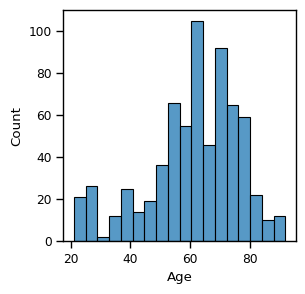

In [9]:
plt.figure(figsize=(3,3))
sns.histplot(merged, x="Age")
print(np.mean(merged["Age"]), np.std(merged["Age"]))

/var/folders/64/ytcycnwx6w936vfxs5_7q3hm0000gn/T/ipykernel_62609/2387794534.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_plot["count"] = 1


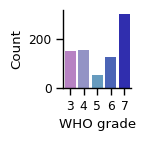

In [ ]:
plt.figure(figsize=(1.5,1.5))
pink_cmap = sns.blend_palette(["#BE77CE", "#589ECD", "#1B19C3"], as_cmap=True)
merged_plot = merged[["Patient Id" ,"WHO grade"]]
merged_plot["count"] = 1
merged_plot = merged_plot.groupby("WHO grade", as_index=False).sum()
sns.barplot(merged_plot, x="WHO grade", y="count", hue="WHO grade", palette=pink_cmap)
plt.legend().remove()
plt.ylabel("Count")
sns.despine()
plt.tight_layout()

<Axes: ylabel='Density'>

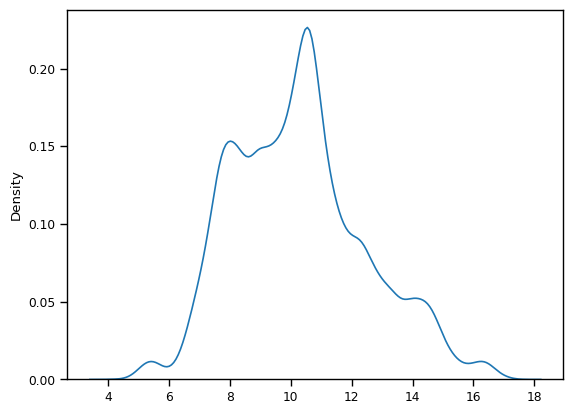

In [44]:
merged[proteins] = merged[proteins].apply(np.log2)

sns.kdeplot(merged[proteins].values.flatten())

In [45]:
batch_means = merged.groupby(["dataset"])[proteins].transform("mean")
mean_of_means = batch_means.mean()
merged[proteins] = merged[proteins] - batch_means + mean_of_means


reducer = umap.UMAP(n_neighbors=15, min_dist=0.5, n_components=2, random_state=42)
embedding = reducer.fit_transform(merged[proteins])

embedding_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
embedding_df["WHO grade"] = merged["WHO grade"].values
embedding_df["dataset"] = merged["dataset"].values
embedding_df["age"] = merged["Age"].values
embedding_df["Max severity"] = merged["Max severity"].values

# impute innsbruck age by kNN on the charite data
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(merged[merged["dataset"]=="Charite"][proteins], merged[merged["dataset"]=="Charite"]["Age"])
merged.loc[merged["dataset"]=="Innsbruck", "Age"] = knn.predict(merged[merged["dataset"]=="Innsbruck"][proteins])

knn.fit(merged[merged["dataset"]=="Charite"][proteins], merged[merged["dataset"]=="Charite"]["Max severity"])
merged.loc[merged["dataset"]=="Innsbruck", "Max severity"] = knn.predict(merged[merged["dataset"]=="Innsbruck"][proteins])
merged["Max severity"] = merged["Max severity"].round().astype(int)

/Users/erikhartman/dev/flow-matching/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='Max severity', ylabel='Count'>

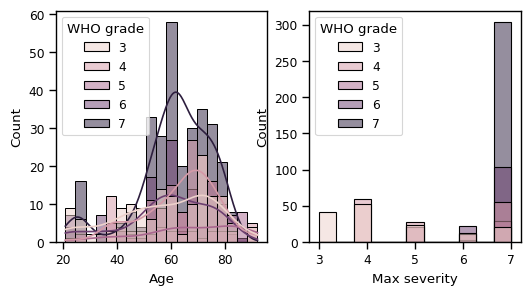

In [46]:
fig, axs = plt.subplots(1,2, figsize=(6,3))
sns.histplot(merged, x="Age", hue="WHO grade", kde=True, ax=axs[0])
sns.histplot(merged, x="Max severity", hue="WHO grade",  ax=axs[1])

      UMAP1      UMAP2  WHO grade  dataset   age  Max severity age_group
0  3.648765   7.037238          7  Charite  53.0           7.0      0-60
1  4.768747  10.516106          6  Charite  69.0           7.0    60-100
2  4.956233  10.769430          6  Charite  69.0           7.0    60-100
3  7.738342   8.242999          6  Charite  60.0           7.0      0-60
4  5.759521   7.485597          7  Charite  81.0           7.0    60-100


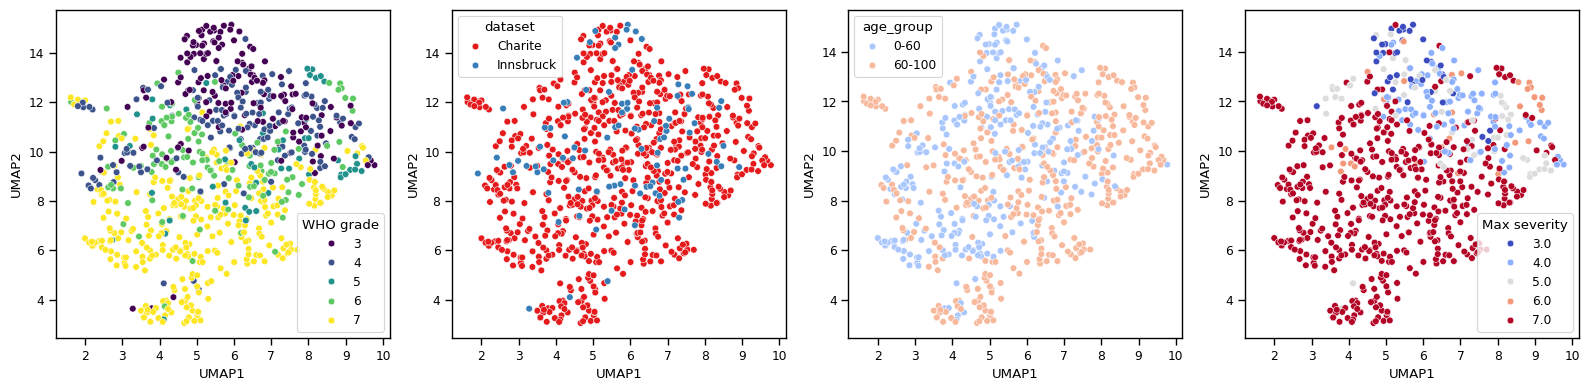

In [47]:
age_bins = [0, 60, 100]
age_labels = ["0-60", "60-100"]
embedding_df["age_group"] = pd.cut(embedding_df["age"], bins=age_bins, labels=age_labels)
print(embedding_df.head())
fig, axs = plt.subplots(1,4, figsize=(16,4))
sns.scatterplot(embedding_df, x="UMAP1", y="UMAP2", hue="WHO grade", palette="viridis", ax=axs[0])
sns.scatterplot(embedding_df, x="UMAP1", y="UMAP2", hue="dataset", palette="Set1", ax=axs[1])
sns.scatterplot(embedding_df, x="UMAP1", y="UMAP2", hue="age_group", palette="coolwarm", ax=axs[2])
sns.scatterplot(embedding_df, x="UMAP1", y="UMAP2", hue="Max severity", palette="coolwarm", ax=axs[3])
plt.tight_layout()

/var/folders/64/ytcycnwx6w936vfxs5_7q3hm0000gn/T/ipykernel_18788/372592837.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["age_group"] = pd.cut(merged["Age"], bins=age_bins, labels=age_labels)


<Axes: xlabel='WHO grade', ylabel='Count'>

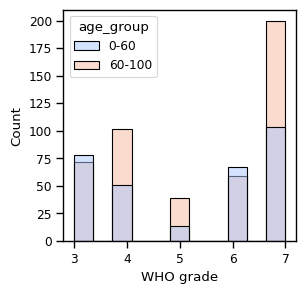

In [48]:
plt.figure(figsize=(3,3))
merged["age_group"] = pd.cut(merged["Age"], bins=age_bins, labels=age_labels)
sns.histplot(merged, x="WHO grade", hue="age_group", palette="coolwarm")

In [49]:
merged

,Patient Id,Time point - days since admission,Time point - days until outcome,WHO grade,Max severity,Patient died,Will worsen in the future,DNI / DNR,Secondary DNI / DNR,Age,...,SERPIND1,GPX3,LUM,C1QC,HBA1,IGKV4-1,dataset,Id,SP.Date,age_group
520_TOF1_AF_002_ZeBanC_P1_A1,123.0,23.0,5.0,7,7,1.0,1.0,0.0,0.0,53.000000,...,9.027521,6.977238,7.755314,9.588932,13.049211,11.193753,Charite,NaN,NaN,0-60
520_TOF1_AF_003_ZeBanC_P1_A2,42.0,21.0,52.0,6,7,0.0,1.0,0.0,0.0,69.000000,...,9.150601,7.451633,8.004602,10.183311,9.042007,11.467400,Charite,NaN,NaN,60-100
520_TOF1_AF_004_ZeBanC_P1_A3,42.0,31.0,42.0,6,7,0.0,0.0,0.0,0.0,69.000000,...,9.476657,7.424879,8.188801,9.804586,10.391346,12.051009,Charite,NaN,NaN,60-100
520_TOF1_AF_005_ZeBanC_P1_A4,109.0,32.0,13.0,6,7,0.0,0.0,0.0,0.0,60.000000,...,8.935241,7.890461,7.522144,9.998503,10.065775,12.418809,Charite,NaN,NaN,0-60
520_TOF1_AF_006_ZeBanC_P1_A5,26.0,34.0,70.0,7,7,1.0,1.0,0.0,1.0,81.000000,...,8.976448,7.587924,8.327163,10.315835,8.916994,11.535782,Charite,NaN,NaN,60-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818_TOF1_AF_147_MKeller-PACovid_P1_H11,NaN,NaN,NaN,6,7,NaN,NaN,NaN,NaN,63.000000,...,9.520651,7.186352,7.932268,10.273287,10.483571,11.454532,Innsbruck,97.0,09.04.2020,60-100
818_TOF1_AF_153_MKeller-PACovid_P2_A8,NaN,NaN,NaN,6,6,NaN,NaN,NaN,NaN,69.333333,...,8.113325,7.659344,8.210977,8.880711,10.431217,9.647871,Innsbruck,98.0,13.05.2020,60-100
818_TOF1_AF_154_MKeller-PACovid_P2_H2,NaN,NaN,NaN,6,7,NaN,NaN,NaN,NaN,57.333333,...,9.276634,7.332264,8.236270,9.704107,9.616332,12.502194,Innsbruck,99.0,09.04.2020,0-60
818_TOF1_AF_158_MKeller-PACovid_P2_F10,NaN,NaN,NaN,6,7,NaN,NaN,NaN,NaN,71.000000,...,8.443337,7.174585,8.114512,9.678014,11.181078,10.969958,Innsbruck,100.0,09.04.2020,60-100


In [ ]:
def compact_raw_file_name(file_name):
    parts = str(file_name).split("_", 1)
    if len(parts) != 2 or not parts[0].isdigit() or len(parts[0]) < 8:
        return file_name
    compact_date = str(int(parts[0][4:]))
    return compact_date + "_" + parts[1]

quant = merged[proteins].reset_index().rename(columns={"index": "File"})

base_meta_cols = [
    "WHO grade",
    "dataset",
    "Max severity",
]
base_meta = (
    merged[base_meta_cols]
    .reset_index()
    .rename(columns={"index": "File", "Age": "age"})
)

raw_meta = pd.read_csv(
    "../../data/covid/raw/meta.tsv",
    sep="	",
    encoding="latin-1",
)
raw_meta["File"] = raw_meta["File.Name"].map(compact_raw_file_name)
raw_meta = raw_meta.drop(columns=["File.Name"], errors="ignore")
raw_meta = raw_meta.rename(
    columns={col: f"raw_{col}" for col in raw_meta.columns if col != "File"}
)

meta = base_meta.merge(raw_meta, on="File", how="left", validate="one_to_one")

quant


,File,ALB,ITIH1,APOB,A2M,C7,KNG1,APOE,C3,CFI,...,ORM1,APOA2,APOC2,PON1,SERPIND1,GPX3,LUM,C1QC,HBA1,IGKV4-1
0,520_TOF1_AF_002_ZeBanC_P1_A1,16.013139,9.898308,11.337749,12.268452,7.852208,11.477159,10.277053,10.823899,8.792189,...,13.315404,9.095824,11.227821,7.815129,9.027521,6.977238,7.755314,9.588932,13.049211,11.193753
1,520_TOF1_AF_003_ZeBanC_P1_A2,16.014342,9.609879,10.448808,12.122808,8.789556,11.044667,10.240047,12.622830,8.897877,...,12.887634,10.474808,10.215095,7.789960,9.150601,7.451633,8.004602,10.183311,9.042007,11.467400
2,520_TOF1_AF_004_ZeBanC_P1_A3,16.071198,10.006955,10.071109,12.415960,8.511789,11.047031,9.044661,12.583121,9.083605,...,12.755654,11.134187,9.999963,7.787857,9.476657,7.424879,8.188801,9.804586,10.391346,12.051009
3,520_TOF1_AF_005_ZeBanC_P1_A4,16.053543,9.362839,10.512244,11.780842,8.552825,11.068614,10.368612,12.416365,8.970323,...,12.213561,10.754368,10.185320,7.982166,8.935241,7.890461,7.522144,9.998503,10.065775,12.418809
4,520_TOF1_AF_006_ZeBanC_P1_A5,15.952487,9.747486,10.655134,12.018233,8.861674,11.011398,10.609551,12.236359,8.845515,...,13.520184,11.015305,10.922042,8.267644,8.976448,7.587924,8.327163,10.315835,8.916994,11.535782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,818_TOF1_AF_147_MKeller-PACovid_P1_H11,15.899707,9.791783,10.922415,12.055386,8.172512,11.124281,9.955586,12.361402,9.018661,...,12.754028,10.067493,10.774329,8.262541,9.520651,7.186352,7.932268,10.273287,10.483571,11.454532
782,818_TOF1_AF_153_MKeller-PACovid_P2_A8,17.274206,9.155469,10.961799,12.231585,8.705485,11.356713,11.468709,12.182376,8.387223,...,13.320689,8.915007,12.145539,7.826430,8.113325,7.659344,8.210977,8.880711,10.431217,9.647871
783,818_TOF1_AF_154_MKeller-PACovid_P2_H2,15.674730,8.862169,10.637574,12.325223,8.444310,11.260661,9.809664,11.828873,9.063537,...,13.236872,10.489513,8.932537,7.963473,9.276634,7.332264,8.236270,9.704107,9.616332,12.502194
784,818_TOF1_AF_158_MKeller-PACovid_P2_F10,15.999697,9.297290,10.597196,12.112971,8.319042,11.030808,10.124736,12.680309,9.231793,...,13.583896,10.681779,9.745532,8.087353,8.443337,7.174585,8.114512,9.678014,11.181078,10.969958
